# RTDA Split-MLP with Output Layer: hls4ml Clean Conversion

Five separate Keras models — one **embed** block, three **solver** blocks, and one **output** block —
run as a stateful inference pipeline. No hls4ml firmware patches needed.

| Model | Inputs | Output | Layers |
|---|---|---|---|
| `embed` | `track(6)` | `emb_out(128)` | Dense×2 + LeakyReLU×2 |
| `solver0` | `emb_out(128)`, `emb_prev(128)` | `s0_out(128)` | Dense×5 + LeakyReLU×4 |
| `solver1` | `s0_out(128)`, `s0_prev(128)` | `s1_out(128)` | (same) |
| `solver2` | `s1_out(128)`, `s1_prev(128)` | `s2_out(128)` | (same) |
| `output` | `mean(s2_out[WARMUP:])` (128) | `pred(27)` | Dense(linear) |

State (`emb_prev`, `s0_prev`, `s1_prev`) is managed by the Python loop (csim) or
`rtda_top.cpp` (synthesis). The output model takes the **mean** of post-warmup `s2_out`
and projects it linearly to 27 dimensions.

In [1]:
import os, warnings
import numpy as np
from pathlib import Path

import hls4ml
import keras
from keras.layers import Input, Dense, Add, LeakyReLU
from keras.models import Model
import tensorflow as tf

warnings.filterwarnings('ignore')
print(f'keras {keras.__version__}  hls4ml {hls4ml.__version__}  '
      f'numpy {np.__version__}  tf {tf.__version__}')

2026-05-12 18:52:48.091279: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-12 18:52:48.116889: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


keras 2.14.0  hls4ml 1.2.0  numpy 1.26.4  tf 2.14.0


In [2]:
NOTEBOOK_DIR = Path(os.getcwd()).resolve()
REPO_ROOT    = NOTEBOOK_DIR if (NOTEBOOK_DIR / 'data').is_dir() else NOTEBOOK_DIR.parent
DATA_DIR     = REPO_ROOT / 'data'
OUT_DIR      = NOTEBOOK_DIR / 'outputs'
OUT_DIR.mkdir(exist_ok=True)

HLS_ROOT     = REPO_ROOT / 'hls_projects'
HLS_DIRS = {
    'embed':   str(HLS_ROOT / 'split_embed'),
    'solver0': str(HLS_ROOT / 'split_solver0'),
    'solver1': str(HLS_ROOT / 'split_solver1'),
    'solver2': str(HLS_ROOT / 'split_solver2'),
    'output':  str(HLS_ROOT / 'split_output'),
}

INPUT_SIZE  = 6
HIDDEN_SIZE = 128
OUTPUT_SIZE = 27
N_TRACKS    = 50
WARMUP      = 3
LEAKY_ALPHA = 0.125  # 0.125 = 2^-3 → zero DSPs in io_stream mode

PART         = 'xcve2802-vsvh1760-2MP-e-S'
STRATEGY     = 'Resource'
REUSE_FACTOR = 256  # Dense(128×128): 128*128/256=64 DSPs
PRECISION    = 'ap_fixed<16,6>'

print(f'DATA_DIR : {DATA_DIR}')
print(f'OUT_DIR  : {OUT_DIR}')
print(f'HLS_ROOT : {HLS_ROOT}')

DATA_DIR : /home/synthara/VersalPrjs/LDRD/quant_rtda/rtda_demo/data
OUT_DIR  : /home/synthara/VersalPrjs/LDRD/quant_rtda/rtda_demo/punit/outputs
HLS_ROOT : /home/synthara/VersalPrjs/LDRD/quant_rtda/rtda_demo/hls_projects


---
### **Hardware Design Note: Why `LEAKY_ALPHA = 0.125` instead of `0.1`**

**This is a deliberate hardware-motivated change, not a numerical accident.**

In `io_stream` mode, hls4ml packs all 128 neurons into one stream word. The LeakyReLU
outer loop runs exactly once, with 128 concurrent multiplications unrolled. With
`alpha=0.1`, none of these map to bit-shifts, costing 128 DSPs per activation.
With `alpha=0.125 = 2^-3`, multiplication becomes a right-shift with zero DSPs.
The pre-trained weights use `alpha=0.1` so there is a small activation mismatch;
this is acceptable for a hardware demonstration.

---

## 1. Keras Models

### Embed block
`track_in(6) → Dense(128) → LeakyReLU → Dense(128) → LeakyReLU → emb_out(128)`

### Solver block (×3)
`[curr(128), prev(128)] → Dense(curr) + Dense(prev) → Add → ReLU → Dense×3 → out(128)`

### Output block
`mean_s2(128) → Dense(27, linear) → pred(27)`

In [3]:
def build_embed_model():
    x = ti = Input(shape=(INPUT_SIZE,), name='track_in')
    x = LeakyReLU(alpha=LEAKY_ALPHA, name='emb_d0_act')(Dense(HIDDEN_SIZE, name='emb_d0')(x))
    x = LeakyReLU(alpha=LEAKY_ALPHA, name='emb_d1_act')(Dense(HIDDEN_SIZE, name='emb_d1')(x))
    return Model(inputs=ti, outputs=x, name='embed')

def build_solver_model(prefix):
    curr = Input(shape=(HIDDEN_SIZE,), name=f'{prefix}_curr')
    prev = Input(shape=(HIDDEN_SIZE,), name=f'{prefix}_prev')
    x = LeakyReLU(alpha=LEAKY_ALPHA, name=f'{prefix}_d0_act')(
        Add(name=f'{prefix}_d0_add')([
            Dense(HIDDEN_SIZE, use_bias=True,  name=f'{prefix}_d0_curr')(curr),
            Dense(HIDDEN_SIZE, use_bias=False, name=f'{prefix}_d0_prev')(prev),
        ])
    )
    for i in range(1, 4):
        x = LeakyReLU(alpha=LEAKY_ALPHA, name=f'{prefix}_d{i}_act')(
            Dense(HIDDEN_SIZE, name=f'{prefix}_d{i}')(x))
    return Model(inputs=[curr, prev], outputs=x, name=f'{prefix}_model')

def build_output_model():
    """Linear Dense(128→27): takes mean(s2_out[WARMUP:]) and projects to 27 dims."""
    inp = Input(shape=(HIDDEN_SIZE,), name='s2_mean')
    out = Dense(OUTPUT_SIZE, use_bias=True, name='out_dense')(inp)
    return Model(inputs=inp, outputs=out, name='output')

embed_model   = build_embed_model()
solver0_model = build_solver_model('s0')
solver1_model = build_solver_model('s1')
solver2_model = build_solver_model('s2')
output_model  = build_output_model()

embed_model.summary()
output_model.summary()

Model: "embed"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 track_in (InputLayer)       [(None, 6)]               0         
                                                                 
 emb_d0 (Dense)              (None, 128)               896       
                                                                 
 emb_d0_act (LeakyReLU)      (None, 128)               0         
                                                                 
 emb_d1 (Dense)              (None, 128)               16512     
                                                                 
 emb_d1_act (LeakyReLU)      (None, 128)               0         
                                                                 
Total params: 17408 (68.00 KB)
Trainable params: 17408 (68.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Model: "output"
_________

In [4]:
def load_parts(stem, n_parts, shape):
    return np.concatenate([
        np.loadtxt(DATA_DIR / f'{stem}_part{i}.txt') for i in range(n_parts)
    ]).reshape(shape).astype(np.float32)

def load_bias(stem):
    return np.loadtxt(DATA_DIR / f'{stem}.txt').astype(np.float32)

# Embed weights
embed_W0 = np.loadtxt(DATA_DIR / 'embed_dense_0_weights.txt').reshape(8, 128)[:6, :].astype(np.float32)
embed_B0 = load_bias('embed_dense_0_bias')
embed_W1 = load_parts('embed_dense_1_weights', 2, (128, 128))
embed_B1 = load_bias('embed_dense_1_bias')

embed_model.get_layer('emb_d0').set_weights([embed_W0, embed_B0])
embed_model.get_layer('emb_d1').set_weights([embed_W1, embed_B1])

# Solver weights
for idx, (model, p) in enumerate([(solver0_model,'s0'), (solver1_model,'s1'), (solver2_model,'s2')]):
    W0 = load_parts(f'solver_{idx}_dense_0_weights', 4, (256, 128))
    B0 = load_bias(f'solver_{idx}_dense_0_bias')
    model.get_layer(f'{p}_d0_curr').set_weights([W0[:128, :], B0])
    model.get_layer(f'{p}_d0_prev').set_weights([W0[128:, :]])
    for d in range(1, 4):
        W = load_parts(f'solver_{idx}_dense_{d}_weights', 2, (128, 128))
        B = load_bias(f'solver_{idx}_dense_{d}_bias')
        model.get_layer(f'{p}_d{d}').set_weights([W, B])

# Output layer weights: output_weights.txt = (128,27), output_bias.txt = (27,)
out_W = np.loadtxt(DATA_DIR / 'output_weights.txt').reshape(128, OUTPUT_SIZE).astype(np.float32)
out_B = load_bias('output_bias')
output_model.get_layer('out_dense').set_weights([out_W, out_B])

print('All weights loaded.')

All weights loaded.


## 2. Reference Outputs (Keras)

Stateful streaming loop: feed one track at a time, pass outputs as states for next track.
Post-warmup `s2_out` is averaged and projected to 27 dims via the Keras output model.

In [5]:
raw    = np.loadtxt(DATA_DIR / 'embed_input.txt', dtype=np.float32)
tracks = raw[:N_TRACKS * 8].reshape(N_TRACKS, 8)[:, :INPUT_SIZE]  # (50, 6)

states = [np.zeros((1, HIDDEN_SIZE), np.float32) for _ in range(3)]
keras_s2out = np.zeros((N_TRACKS, HIDDEN_SIZE), np.float32)
keras_states = []

for j in range(N_TRACKS):
    keras_states.append(tuple(s.copy() for s in states))
    emb = embed_model(tracks[j:j+1], training=False).numpy()         # (1,128)
    s0  = solver0_model([emb,        states[0]], training=False).numpy()
    s1  = solver1_model([s0,         states[1]], training=False).numpy()
    s2  = solver2_model([s1,         states[2]], training=False).numpy()
    keras_s2out[j] = s2
    states[0], states[1], states[2] = emb, s0, s1

# mean over post-warmup tracks → (1,128) → output model → (1,27) → ravel to (27,)
s2_mean_keras = keras_s2out[WARMUP:].mean(axis=0, keepdims=True)        # (1,128)
keras_27dim   = output_model(s2_mean_keras, training=False).numpy().ravel()  # (27,)

np.savetxt(OUT_DIR / 'keras_s2out.txt', keras_s2out, fmt='%.8e')
np.savetxt(OUT_DIR / 'keras_27dim.txt', keras_27dim, fmt='%.8e')

aie_s2 = np.loadtxt(DATA_DIR / 'aieml10_output_aie.txt', dtype=np.float32).reshape(N_TRACKS, HIDDEN_SIZE)
diffs = [np.max(np.abs(keras_s2out[j] - aie_s2[j])) for j in range(WARMUP, N_TRACKS)]
print(f'Keras vs AIE hw  max|diff| = {max(diffs):.2e}')
print(f'keras_s2out  saved → outputs/keras_s2out.txt')
print(f'keras_27dim  saved → outputs/keras_27dim.txt')

Keras vs AIE hw  max|diff| = 9.43e-02
keras_s2out  saved → outputs/keras_s2out.txt
keras_27dim  saved → outputs/keras_27dim.txt


## 3. hls4ml Conversion

Five models converted: embed, solver0–2, output.
Config: `io_stream`, `Resource` strategy, `ReuseFactor=256`, `ap_fixed<16,6>`.
The output Dense(128→27) uses RF=128 (largest valid divisor ≤256 of 128×27=3456).

In [6]:
def make_hls_config(keras_model, reuse=None):
    if reuse is None:
        reuse = REUSE_FACTOR
    cfg = hls4ml.utils.config_from_keras_model(keras_model, granularity='name', backend='Vitis')
    cfg['Model']['Strategy']    = STRATEGY
    cfg['Model']['ReuseFactor'] = reuse
    cfg['Model']['Precision']   = PRECISION
    for lname in cfg.get('LayerName', {}):
        cfg['LayerName'][lname]['Precision']   = {'accum': 'ap_fixed<32,18>'}
        cfg['LayerName'][lname]['ReuseFactor'] = reuse
    return cfg

def patch_vivado_tcl(out_dir):
    # hls4ml 1.2.0 emits -bram_power_opt which Vivado 2024.x dropped.
    # Removing it has no effect on LUT/FF/DSP results — it was an optional
    # BRAM power-reduction pass, not required for correct implementation.
    tcl = Path(out_dir) / 'vivado_synth.tcl'
    if tcl.is_file():
        original = tcl.read_text()
        patched  = original.replace(' -bram_power_opt', '')
        if patched != original:
            tcl.write_text(patched)
            print(f'  patched vivado_synth.tcl (removed -bram_power_opt)')

# Dense(128→27): valid RF must divide 128*27=3456. Largest ≤256 that does: 128.
OUTPUT_RF = 128

models_to_convert = [
    ('embed',   embed_model,   HLS_DIRS['embed'],   REUSE_FACTOR),
    ('solver0', solver0_model, HLS_DIRS['solver0'], REUSE_FACTOR),
    ('solver1', solver1_model, HLS_DIRS['solver1'], REUSE_FACTOR),
    ('solver2', solver2_model, HLS_DIRS['solver2'], REUSE_FACTOR),
    ('output',  output_model,  HLS_DIRS['output'],  OUTPUT_RF),
]

hls_models = {}
for name, km, out_dir, rf in models_to_convert:
    hls_m = hls4ml.converters.convert_from_keras_model(
        km,
        hls_config  = make_hls_config(km, reuse=rf),
        output_dir  = out_dir,
        backend     = 'Vitis',
        part        = PART,
        io_type     = 'io_stream',
    )
    hls_m.write()
    patch_vivado_tcl(out_dir)
    hls_models[name] = hls_m
    print(f'{name:8s}  →  {out_dir}')

print('\nAll 5 models written.')

embed     →  /home/synthara/VersalPrjs/LDRD/quant_rtda/rtda_demo/hls_projects/split_embed
solver0   →  /home/synthara/VersalPrjs/LDRD/quant_rtda/rtda_demo/hls_projects/split_solver0
solver1   →  /home/synthara/VersalPrjs/LDRD/quant_rtda/rtda_demo/hls_projects/split_solver1
solver2   →  /home/synthara/VersalPrjs/LDRD/quant_rtda/rtda_demo/hls_projects/split_solver2
output    →  /home/synthara/VersalPrjs/LDRD/quant_rtda/rtda_demo/hls_projects/split_output

All 5 models written.


In [7]:
%%time
HLS_COMPILED = {}
for name, hls_m in hls_models.items():
    try:
        hls_m.compile()
        HLS_COMPILED[name] = True
        print(f'{name:8s}  compiled OK')
    except Exception as e:
        HLS_COMPILED[name] = False
        print(f'{name:8s}  FAILED: {e}')

embed     compiled OK
solver0   compiled OK
solver1   compiled OK
solver2   compiled OK
output    compiled OK
CPU times: user 470 ms, sys: 69.2 ms, total: 539 ms
Wall time: 16.7 s


## 4. C-Simulation & Comparison

Stateful track loop with hls4ml csim for embed/solver0–2, then one forward pass
through the hls4ml output model on the post-warmup mean.

In [8]:
if all(HLS_COMPILED.values()):
    hls_s2out = np.zeros((N_TRACKS, HIDDEN_SIZE), np.float32)
    st = [np.zeros((1, HIDDEN_SIZE), np.float32) for _ in range(3)]

    def _p(m, xs):
        """Feed inputs to hls4ml model, return (1, n_out) array."""
        xs = [np.asarray(x).reshape(1, -1) for x in xs] if isinstance(xs, list) \
             else np.asarray(xs).reshape(1, -1)
        return np.asarray(m.predict(xs)).reshape(1, -1)

    for j in range(N_TRACKS):
        emb = _p(hls_models['embed'],   tracks[j:j+1])
        s0  = _p(hls_models['solver0'], [emb, st[0]])
        s1  = _p(hls_models['solver1'], [s0,  st[1]])
        s2  = _p(hls_models['solver2'], [s1,  st[2]])
        hls_s2out[j] = s2.ravel()
        st[0], st[1], st[2] = emb, s0, s1

    # Apply output model to post-warmup mean — one forward pass through hls4ml csim
    s2_mean_hls = hls_s2out[WARMUP:].mean(axis=0, keepdims=True)      # (1,128)
    hls_27dim   = np.asarray(hls_models['output'].predict(s2_mean_hls)).ravel()  # (27,)

    np.savetxt(OUT_DIR / 'hls_s2out.txt',  hls_s2out,  fmt='%.8e')
    np.savetxt(OUT_DIR / 'hls_27dim.txt',  hls_27dim,  fmt='%.8e')

    hdr = f'{"track":>6}  {"max|diff|_128":>14}  {"rms|diff|_128":>14}'
    print(hdr)
    print('-' * len(hdr))
    for j in range(N_TRACKS):
        d = np.abs(hls_s2out[j] - keras_s2out[j])
        if j < 5 or j >= N_TRACKS - 3:
            print(f'{j:6d}  {d.max():14.4e}  {np.sqrt((d**2).mean()):14.4e}')

    print()
    diff_27 = np.abs(hls_27dim - keras_27dim)
    print(f'27-dim output  max|diff|={diff_27.max():.4e}  rms={np.sqrt((diff_27**2).mean()):.4e}')
    print(f'correlation (Keras vs hls4ml, 27-dim) = {np.corrcoef(hls_27dim, keras_27dim)[0,1]:.4f}')
    print('hls_s2out/hls_27dim saved -> outputs/')
else:
    print('Skipped: not all models compiled. Check errors above.')

 track   max|diff|_128   rms|diff|_128
--------------------------------------
     0      2.4923e-02      8.1546e-03
     1      6.3465e-02      1.9417e-02
     2      1.2112e-01      3.4597e-02
     3      9.3764e-02      2.4919e-02
     4      8.8863e-02      2.6132e-02
    47      7.0109e-02      1.9707e-02
    48      7.5938e-02      2.0530e-02
    49      7.3162e-02      2.1223e-02

27-dim output  max|diff|=2.6393e-02  rms=1.1922e-02
correlation (Keras vs hls4ml, 27-dim) = 0.8608
hls_s2out/hls_27dim saved -> outputs/


## 5. Comparison Plots

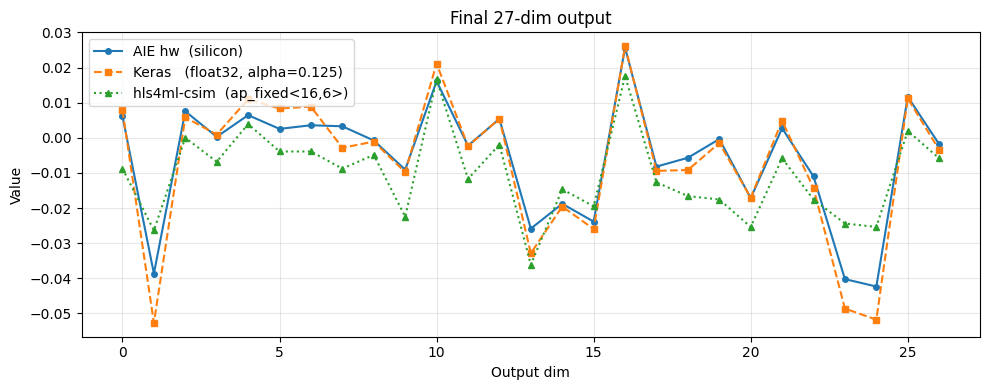

Keras  vs AIE    max|diff|=0.0140  rms=0.0047
hls4ml vs AIE    max|diff|=0.0172  rms=0.0097
hls4ml vs Keras  max|diff|=0.0264  rms=0.0119


In [9]:
import matplotlib.pyplot as plt

# All three 27-dim outputs
aie_27   = aie_s2[WARMUP:].mean(axis=0)      @ out_W + out_B  # AIE ref (manual projection)
keras_27_ref = keras_27dim   # from output_model Keras forward pass
hls_27_ref   = hls_27dim     # from hls4ml output model csim

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(aie_27,       'o-',  label='AIE hw  (silicon)',              ms=4)
ax.plot(keras_27_ref, 's--', label='Keras   (float32, alpha=0.125)', ms=4)
ax.plot(hls_27_ref,   '^:',  label='hls4ml-csim  (ap_fixed<16,6>)',  ms=4)
ax.set_xlabel('Output dim'); ax.set_ylabel('Value')
ax.set_title('Final 27-dim output'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'compare_27dim.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'Keras  vs AIE    max|diff|={np.abs(keras_27_ref-aie_27).max():.4f}  '
      f'rms={np.sqrt(np.mean((keras_27_ref-aie_27)**2)):.4f}')
print(f'hls4ml vs AIE    max|diff|={np.abs(hls_27_ref -aie_27).max():.4f}  '
      f'rms={np.sqrt(np.mean((hls_27_ref -aie_27)**2)):.4f}')
print(f'hls4ml vs Keras  max|diff|={np.abs(hls_27_ref-keras_27_ref).max():.4f}  '
      f'rms={np.sqrt(np.mean((hls_27_ref-keras_27_ref)**2)):.4f}')

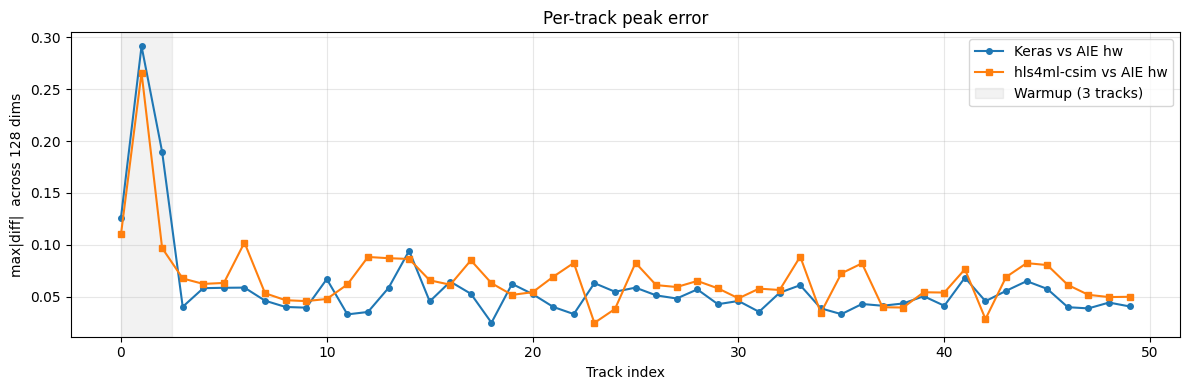

In [10]:
# Per-track max error across 128 dims
diff_keras = [np.abs(keras_s2out[j] - aie_s2[j]).max() for j in range(N_TRACKS)]
diff_hls   = [np.abs(hls_s2out[j]   - aie_s2[j]).max() for j in range(N_TRACKS)]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(diff_keras, 'o-', ms=4, label='Keras vs AIE hw')
ax.plot(diff_hls,   's-', ms=4, label='hls4ml-csim vs AIE hw')
ax.axvspan(0, WARMUP - 0.5, alpha=0.1, color='gray', label=f'Warmup ({WARMUP} tracks)')
ax.set_xlabel('Track index'); ax.set_ylabel('max|diff|  across 128 dims')
ax.set_title('Per-track peak error'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'compare_pertrack.png', dpi=100, bbox_inches='tight')
plt.show()

In [ ]:
# Scatter: hls4ml vs Keras on 27-dim output
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
lo, hi = min(keras_27_ref.min(), hls_27_ref.min()), max(keras_27_ref.max(), hls_27_ref.max())
ax.scatter(keras_27_ref, hls_27_ref, s=20, zorder=3)
ax.plot([lo, hi], [lo, hi], 'k--', lw=1, label='ideal')
ax.set_xlabel('Keras output'); ax.set_ylabel('hls4ml-csim output')
ax.set_title('hls4ml vs Keras — 27-dim'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
lo2, hi2 = min(aie_27.min(), hls_27_ref.min()), max(aie_27.max(), hls_27_ref.max())
ax.scatter(aie_27, hls_27_ref, s=20, color='tab:orange', zorder=3)
ax.plot([lo2, hi2], [lo2, hi2], 'k--', lw=1, label='ideal')
ax.set_xlabel('AIE hw output'); ax.set_ylabel('hls4ml-csim output')
ax.set_title('hls4ml vs AIE hw — 27-dim'); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'compare_scatter_27dim.png', dpi=100, bbox_inches='tight')
plt.show()

## 6. C-Synthesis

Runs Vitis HLS synthesis for each model. Expect ~1.5 hr for solvers.
Edit `SYNTH_MODELS` to run a subset.

In [12]:
SYNTH_MODELS = ['embed', 'solver0', 'solver1', 'solver2', 'output']
# SYNTH_MODELS = ['embed', 'solver0', 'output']
# SYNTH_MODELS = ['output']  # uncomment to test just the output block

for name in SYNTH_MODELS:
    print(f'\n===== Synthesising {name} =====')
    hls_models[name].build(csim=False, synth=True, cosim=False, vsynth=True)
    print(f'{name} done.')


===== Synthesising embed =====

****** vitis-run v2024.2 (64-bit)
  **** SW Build 5239630 on 2024-11-10-11:19:46
  **** Start of session at: Tue May 12 18:54:28 2026
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2024 Advanced Micro Devices, Inc. All Rights Reserved.

  **** HLS Build v2024.2 5238294
Sourcing Tcl script '/home/synthara/VersalPrjs/LDRD/quant_rtda/rtda_demo/hls_projects/split_embed/build_prj.tcl'
INFO: [HLS 200-1510] Running: open_project myproject_prj 
INFO: [HLS 200-10] Opening project '/home/synthara/VersalPrjs/LDRD/quant_rtda/rtda_demo/hls_projects/split_embed/myproject_prj'.
INFO: [HLS 200-1510] Running: set_top myproject 
INFO: [HLS 200-1510] Running: add_files firmware/myproject.cpp -cflags -std=c++0x 
INFO: [HLS 200-10] Adding design file 'firmware/myproject.cpp' to the project
INFO: [HLS 200-1510] Running: add_files -tb myproject_test.cpp -cflags -std=c++0x 
INFO: [HLS 200-10] Adding test bench file 'myproject_test.cpp' to th

INFO: [HLS 200-1995] There were 13,544 instructions in the design after the 'Unroll/Inline (step 2)' phase of compilation. See the Design Size Report for more details: /home/synthara/VersalPrjs/LDRD/quant_rtda/rtda_demo/hls_projects/split_embed/myproject_prj/solution1/syn/report/csynth_design_size.rpt
INFO: [HLS 200-1995] There were 11,780 instructions in the design after the 'Unroll/Inline (step 3)' phase of compilation. See the Design Size Report for more details: /home/synthara/VersalPrjs/LDRD/quant_rtda/rtda_demo/hls_projects/split_embed/myproject_prj/solution1/syn/report/csynth_design_size.rpt
INFO: [HLS 200-1995] There were 7,940 instructions in the design after the 'Unroll/Inline (step 4)' phase of compilation. See the Design Size Report for more details: /home/synthara/VersalPrjs/LDRD/quant_rtda/rtda_demo/hls_projects/split_embed/myproject_prj/solution1/syn/report/csynth_design_size.rpt
INFO: [HLS 200-1995] There were 51,710 instructions in the design after the 'Array/Struct' p

INFO: [HLS 200-111] Finished Standard Transforms: CPU user time: 2.8 seconds. CPU system time: 0.05 seconds. Elapsed time: 2.84 seconds; current allocated memory: 790.352 MB.
INFO: [HLS 200-10] Checking synthesizability ...
INFO: [HLS 200-111] Finished Checking Synthesizability: CPU user time: 352.27 seconds. CPU system time: 0.13 seconds. Elapsed time: 352.42 seconds; current allocated memory: 897.668 MB.
INFO: [XFORM 203-602] Inlining function 'nnet::cast<ap_fixed<16, 6, (ap_q_mode)5, (ap_o_mode)3, 0>, ap_fixed<16, 6, (ap_q_mode)5, (ap_o_mode)3, 0>, config2>' into 'nnet::dense_resource_rf_gt_nin_rem0<ap_fixed<16, 6, (ap_q_mode)5, (ap_o_mode)3, 0>, ap_fixed<16, 6, (ap_q_mode)5, (ap_o_mode)3, 0>, config2>' (firmware/nnet_utils/nnet_dense_resource.h:164) automatically.
INFO: [XFORM 203-602] Inlining function 'nnet::cast<ap_fixed<16, 6, (ap_q_mode)5, (ap_o_mode)3, 0>, ap_fixed<16, 6, (ap_q_mode)5, (ap_o_mode)3, 0>, config5>' into 'nnet::dense_resource_rf_gt_nin_rem0<ap_fixed<16, 6, (ap_q

INFO: [SCHED 204-61] Pipelining loop 'ReuseLoop'.
INFO: [HLS 200-1470] Pipelining result : Target II = 1, Final II = 1, Depth = 3, loop 'ReuseLoop'
INFO: [SCHED 204-11] Finished scheduling.
INFO: [HLS 200-111] Finished Scheduling: CPU user time: 1.7 seconds. CPU system time: 0 seconds. Elapsed time: 1.71 seconds; current allocated memory: 1.591 GB.
INFO: [BIND 205-100] Starting micro-architecture generation ...
INFO: [BIND 205-101] Performing variable lifetime analysis.
INFO: [BIND 205-101] Exploring resource sharing.
INFO: [BIND 205-101] Binding ...
INFO: [BIND 205-100] Finished micro-architecture generation.
INFO: [HLS 200-111] Finished Binding: CPU user time: 0.26 seconds. CPU system time: 0.02 seconds. Elapsed time: 0.27 seconds; current allocated memory: 1.591 GB.
INFO: [HLS 200-10] ----------------------------------------------------------------
INFO: [HLS 200-42] -- Implementing module 'dense_array_ap_fixed_128u_array_ap_fixed_16_6_5_3_0_128u_config5_s' 
INFO: [HLS 200-10] -----

INFO: [HLS 200-10] ----------------------------------------------------------------
INFO: [HLS 200-10] -- Generating RTL for module 'dense_array_ap_fixed_128u_array_ap_fixed_16_6_5_3_0_128u_config5_s' 
INFO: [HLS 200-10] ----------------------------------------------------------------
INFO: [RTGEN 206-100] Finished creating RTL model for 'dense_array_ap_fixed_128u_array_ap_fixed_16_6_5_3_0_128u_config5_s'.
INFO: [HLS 200-111] Finished Creating RTL model: CPU user time: 0.9 seconds. CPU system time: 0.09 seconds. Elapsed time: 0.99 seconds; current allocated memory: 1.591 GB.
INFO: [HLS 200-10] ----------------------------------------------------------------
INFO: [HLS 200-10] -- Generating RTL for module 'leaky_relu_array_ap_fixed_array_ap_fixed_128u_LeakyReLU_config7_s' 
INFO: [HLS 200-10] ----------------------------------------------------------------
INFO: [RTGEN 206-100] Finished creating RTL model for 'leaky_relu_array_ap_fixed_array_ap_fixed_128u_LeakyReLU_config7_s'.
INFO: [HLS

...

INFO: [Synth 8-4490] FSM extraction disabled for register 'ap_CS_fsm_reg' through user attribute
---------------------------------------------------------------------------------
Finished Synthesize : Time (s): cpu = 00:00:04 ; elapsed = 00:00:04 . Memory (MB): peak = 2071.348 ; gain = 16.996 ; free physical = 341345 ; free virtual = 374741
---------------------------------------------------------------------------------
---------------------------------------------------------------------------------
Finished Constraint Validation : Time (s): cpu = 00:00:04 ; elapsed = 00:00:05 . Memory (MB): peak = 2087.191 ; gain = 32.840 ; free physical = 341355 ; free virtual = 374751
---------------------------------------------------------------------------------
---------------------------------------------------------------------------------
Start Loading Part and Timing Information
---------------------------------------------------------------------------------
Loading part: xcve2802-vsvh176

---------------------------------------------------------------------------------
Finished Cross Boundary and Area Optimization : Time (s): cpu = 00:00:17 ; elapsed = 00:00:18 . Memory (MB): peak = 3450.809 ; gain = 1396.457 ; free physical = 340020 ; free virtual = 373431
---------------------------------------------------------------------------------
 Sort Area is  mul_16s_16s_32_1_1_U10/tmp_product_a : 0 0 : 1667 1667 : Used 1 time 0
 Sort Area is  mul_16s_16s_32_1_1_U11/tmp_product_b : 0 0 : 1667 1667 : Used 1 time 0
 Sort Area is  mul_16s_16s_32_1_1_U12/tmp_product_c : 0 0 : 1667 1667 : Used 1 time 0
 Sort Area is  mul_16s_16s_32_1_1_U13/tmp_product_d : 0 0 : 1667 1667 : Used 1 time 0
 Sort Area is  mul_16s_16s_32_1_1_U14/tmp_product_e : 0 0 : 1667 1667 : Used 1 time 0
 Sort Area is  mul_16s_16s_32_1_1_U15/tmp_product_f : 0 0 : 1667 1667 : Used 1 time 0
 Sort Area is  mul_16s_16s_32_1_1_U16/tmp_product_10 : 0 0 : 1667 1667 : Used 1 time 0
 Sort Area is  mul_16s_16s_32_1_1_U17/tmp

No constraint files found.
---------------------------------------------------------------------------------
Start Timing Optimization
---------------------------------------------------------------------------------
---------------------------------------------------------------------------------
Finished Timing Optimization : Time (s): cpu = 00:00:18 ; elapsed = 00:00:18 . Memory (MB): peak = 3450.809 ; gain = 1396.457 ; free physical = 340034 ; free virtual = 373445
---------------------------------------------------------------------------------
---------------------------------------------------------------------------------
Start Technology Mapping
---------------------------------------------------------------------------------
INFO: [Synth 8-11322] No global retiming is needed without any clock constraint
INFO: [Synth 8-7052] The timing for the instance dense_array_ap_fixed_128u_array_ap_fixed_16_6_5_3_0_27u_config2_U0/grp_dense_resource_rf_leq_nin_ap_fixed_ap_fixed_16_6_5_3_0_

Netlist sorting complete. Time (s): cpu = 00:00:00.11 ; elapsed = 00:00:00.12 . Memory (MB): peak = 3450.816 ; gain = 0.000 ; free physical = 340211 ; free virtual = 373622
INFO: [Netlist 29-17] Analyzing 1113 Unisim elements for replacement
INFO: [Netlist 29-28] Unisim Transformation completed in 0 CPU seconds
INFO: [Constraints 18-6358] GCLK_DESKEW_DEFAULT not specified in Clock Expansion Window constraints config file for device xcve2802.  GCLK Deskew mode will be Off and cannot be enabled via GCLK_DESKEW override.
INFO: [Constraints 18-5720] The default GCLK Deskew mode is Off.
INFO: [Device 21-9335] Optimized delay calculation is enabled for this device.
INFO: [Constraints 18-13227] Created floorplan with Advanced Flow Feature Set
INFO: [Project 1-570] Preparing netlist for logic optimization
INFO: [Opt 31-138] Pushed 0 inverter(s) to 0 load pin(s).
INFO: [Opt 31-422] The CLOCK_DOMAINS attribute on the BRAM cell dense_array_ap_fixed_128u_array_ap_fixed_16_6_5_3_0_27u_config2_U0/gr

Phase 8.1 Finalizing Design Cores and Updating Shapes | Checksum: 12b756c2b

Time (s): cpu = 00:00:23 ; elapsed = 00:00:21 . Memory (MB): peak = 5237.973 ; gain = 1593.387 ; free physical = 338812 ; free virtual = 372223

Phase 8.2 Verifying Netlist Connectivity
Phase 8.2 Verifying Netlist Connectivity | Checksum: 12b756c2b

Time (s): cpu = 00:00:23 ; elapsed = 00:00:21 . Memory (MB): peak = 5237.973 ; gain = 1593.387 ; free physical = 338812 ; free virtual = 372223
Phase 8 Finalization | Checksum: 12b756c2b

Time (s): cpu = 00:00:23 ; elapsed = 00:00:21 . Memory (MB): peak = 5237.973 ; gain = 1593.387 ; free physical = 338812 ; free virtual = 372223
Opt_design Change Summary


-------------------------------------------------------------------------------------------------------------------------
|  Phase                        |  #Cells created  |  #Cells Removed  |  #Constrained objects preventing optimizations  |
---------------------------------------------------------------------

## 7. Synthesis Reports

In [13]:
def print_report(name):
    rpt = Path(HLS_DIRS[name]) / 'myproject_prj' / 'solution1' / 'syn' / 'report' / 'myproject_csynth.rpt'
    if not rpt.is_file():
        print(f'{name:8s}  synthesis not done yet')
        return
    txt = rpt.read_text().splitlines()

    timing = ''
    for i, line in enumerate(txt):
        if '+ Timing:' in line:
            for l in txt[i:i+8]:
                if l.startswith('    |ap_clk'):
                    timing = l.strip()
                    break
            break

    util = []
    for i, line in enumerate(txt):
        if '== Utilization Estimates' in line:
            for l in txt[i:i+40]:
                if l.startswith('|Total') or l.startswith('|Available') or l.startswith('|Utilization'):
                    util.append(l.rstrip())
                if l.startswith('|Utilization'):
                    break
            break

    print(f'===== {name} =====')
    print(f'  {rpt}')
    if timing: print(f'  Timing: {timing}')
    for u in util:
        print(f'  {u}')
    print()

for name in ['embed', 'solver0', 'solver1', 'solver2', 'output']:
    print_report(name)

===== embed =====
  /home/synthara/VersalPrjs/LDRD/quant_rtda/rtda_demo/hls_projects/split_embed/myproject_prj/solution1/syn/report/myproject_csynth.rpt
  Timing: |ap_clk  |  5.00 ns|  3.595 ns|     1.35 ns|
  |Total            |       33|    68|    22149|   49905|    0|
  |Available        |     1200|  1312|  1041408|  520704|  264|
  |Utilization (%)  |        2|     5|        2|       9|    0|

===== solver0 =====
  /home/synthara/VersalPrjs/LDRD/quant_rtda/rtda_demo/hls_projects/split_solver0/myproject_prj/solution1/syn/report/myproject_csynth.rpt
  Timing: |ap_clk  |  5.00 ns|  3.548 ns|     1.35 ns|
  |Total            |      150|   320|    64428|  150308|    0|
  |Available        |     1200|  1312|  1041408|  520704|  264|
  |Utilization (%)  |       12|    24|        6|      28|    0|

===== solver1 =====
  /home/synthara/VersalPrjs/LDRD/quant_rtda/rtda_demo/hls_projects/split_solver1/myproject_prj/solution1/syn/report/myproject_csynth.rpt
  Timing: |ap_clk  |  5.00 ns|  3.548

## 8. ONNX Export (optional)

In [ ]:
SYNTH_MODELS = ['output']
# SYNTH_MODELS = ['output']  # uncomment to test just the output block

for name in SYNTH_MODELS:
    print(f'\n===== Synthesising {name} =====')
    hls_models[name].build(csim=False, synth=False, cosim=False, vsynth=True)
    print(f'{name} done.')

In [ ]:
# Uncomment if tf2onnx is not yet installed:
# import subprocess; subprocess.run(['pip', 'install', 'tf2onnx', 'onnxruntime'], check=True)

import tf2onnx
import onnx

onnx_models = [
    ('embed',   embed_model),
    ('solver0', solver0_model),
    ('solver1', solver1_model),
    ('solver2', solver2_model),
    ('output',  output_model),
]

for name, km in onnx_models:
    out_path = str(OUT_DIR / f'{name}.onnx')
    input_sig = [tf.TensorSpec(inp.shape, tf.float32, name=inp.name.split(':')[0])
                 for inp in km.inputs]
    model_proto, _ = tf2onnx.convert.from_keras(km, input_signature=input_sig, opset=13)
    onnx.save(model_proto, out_path)
    print(f'{name:8s}  →  {out_path}')